In [1]:
pip install opencv-python tqdm scikit-image

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 103.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 101.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]]

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, random
import numpy as np
from pathlib import Path
from collections import defaultdict

import cv2
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tqdm.auto import tqdm

# ========= CONFIG =========
DATA_ROOT = Path("vault")          # contains 0001..4000 folders
MASK_ROOT = Path("masks")         # will be created
SEED = 42

IMG_SIZE = (512, 512)
BATCH_SIZE_DL = 8
BATCH_SIZE_GAN = 4               # GAN is heavier; increase if stable
MAX_GROUPS = 1000                # you requested 1000 groups

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Optional: Mixed precision for H100 (recommended for Pix2Pix)
tf.keras.mixed_precision.set_global_policy("mixed_float16")

In [3]:
PAIR_RE = re.compile(r"(?:c|cf)-(\d+)-(\d+)\.jpg$", re.IGNORECASE)

def build_pairs_for_group_duplicates(gdir: Path, masks_root=MASK_ROOT, max_k=60):
    """
    Duplicate-safe pairing:
      idx -> list(paths)
      for each odd k: pair clean[k][i] with noisy[k+1][i]
      mask name includes instance index i: m-<gid>-<k>-<i>.png
    Returns:
      pix2pix_pairs: list[(noisy, clean)]
      deeplab_pairs: list[(noisy, mask_path)]
    """
    gid = gdir.name  # "0577"
    idx_to_paths = defaultdict(list)

    for p in sorted(gdir.glob("*.jpg")):
        m = PAIR_RE.search(p.name)
        if m:
            idx = int(m.group(2))
            idx_to_paths[idx].append(p)

    for idx in idx_to_paths:
        idx_to_paths[idx].sort(key=lambda x: x.name)

    pix_pairs, dl_pairs = [], []

    for k in range(1, max_k, 2):  # odd indices
        cleans = idx_to_paths.get(k, [])
        noisies = idx_to_paths.get(k+1, [])
        n = min(len(cleans), len(noisies))
        for i in range(n):
            clean_p = cleans[i]
            noisy_p = noisies[i]

            pix_pairs.append((str(noisy_p), str(clean_p)))

            mask_path = masks_root / gid / f"m-{int(gid):04d}-{k}-{i:02d}.png"
            dl_pairs.append((str(noisy_p), str(mask_path)))

    return pix_pairs, dl_pairs

In [4]:
def split_groups(train=0.8, val=0.1, max_groups=MAX_GROUPS):
    group_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

    # limit to first max_groups but shuffle deterministically
    group_dirs = group_dirs[:max_groups]
    rng = random.Random(SEED)
    rng.shuffle(group_dirs)

    n = len(group_dirs)
    n_train = int(train * n)
    n_val = int(val * n)

    train_g = group_dirs[:n_train]
    val_g = group_dirs[n_train:n_train+n_val]
    test_g = group_dirs[n_train+n_val:]
    return train_g, val_g, test_g

def build_split_pairs(group_list, desc):
    pix, dl = [], []
    for gdir in tqdm(group_list, desc=desc):
        p, d = build_pairs_for_group_duplicates(gdir)
        pix.extend(p)
        dl.extend(d)
    return pix, dl

train_g, val_g, test_g = split_groups(max_groups=MAX_GROUPS)

pix_train, dl_train = build_split_pairs(train_g, "Pairing TRAIN")
pix_val,   dl_val   = build_split_pairs(val_g,   "Pairing VAL")
pix_test,  dl_test  = build_split_pairs(test_g,  "Pairing TEST")

len(pix_train), len(pix_val), len(pix_test), len(dl_train), len(dl_val), len(dl_test)

Pairing TRAIN:   0%|          | 0/800 [00:00<?, ?it/s]

Pairing VAL:   0%|          | 0/100 [00:00<?, ?it/s]

Pairing TEST:   0%|          | 0/100 [00:00<?, ?it/s]

(43146, 5400, 5400, 43146, 5400, 5400)

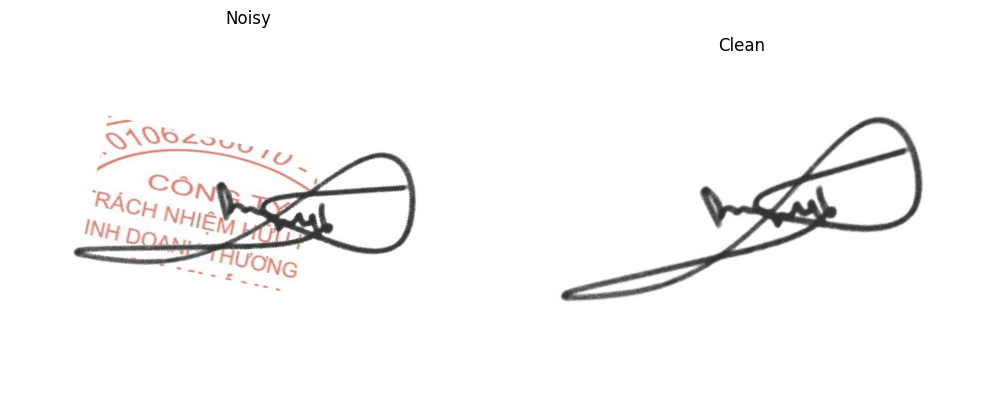

In [5]:
def show_pix2pix_pair(pair):
    noisy_path, clean_path = pair
    noisy = np.array(Image.open(noisy_path).convert("RGB"))
    clean = np.array(Image.open(clean_path).convert("RGB"))

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(noisy); plt.title("Noisy"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(clean); plt.title("Clean"); plt.axis("off")
    plt.tight_layout(); plt.show()

show_pix2pix_pair(random.choice(pix_train))

In [6]:
def make_signature_mask_from_clean_bgr(clean_bgr,
                                       min_area=20,
                                       close_ksize=3,
                                       close_iter=1,
                                       sat_thr=60,
                                       val_thr=60):
    """
    Pseudo-GT from CLEAN image (BGR):
      1) stamp suppression by HSV: red range + general high-saturation regions
      2) ink extraction via Otsu on grayscale (inverse)
      3) connected components filter (keep thin strokes)
      4) light morphological close (connect breaks, minimal thickening)
    Returns uint8 mask {0,255}
    """
    hsv = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # Red-ish stamps (wrap-around)
    stamp_red = ((s > 80) & (v > 50) & (((h >= 0) & (h <= 15)) | ((h >= 160) & (h <= 180))))
    stamp_red = stamp_red.astype(np.uint8) * 255

    # General stamp suppression: high saturation (captures brown/orange/faded stamps)
    stamp_sat = ((s >= sat_thr) & (v >= val_thr)).astype(np.uint8) * 255

    k_stamp = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    stamp_any = cv2.max(stamp_red, stamp_sat)
    stamp_any = cv2.dilate(stamp_any, k_stamp, iterations=1)

    # Ink via Otsu
    gray = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Remove stamp pixels
    bw[stamp_any > 0] = 0

    # CC filter
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)
    cleaned = np.zeros_like(bw)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 255

    # Light close to connect minor gaps (no dilation)
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, k_close, iterations=close_iter)

    return cleaned

In [7]:
from tqdm import tqdm

def generate_masks_for_groups(group_list, max_k=60, min_area=20):
    total = 0
    for gdir in tqdm(group_list, desc="Generating masks"):
        gid = gdir.name
        out_dir = MASK_ROOT / gid
        out_dir.mkdir(parents=True, exist_ok=True)

        # build idx -> list(paths) to handle duplicates
        idx_to_paths = defaultdict(list)
        for p in sorted(gdir.glob("*.jpg")):
            m = PAIR_RE.search(p.name)
            if m:
                idx_to_paths[int(m.group(2))].append(p)

        for idx in idx_to_paths:
            idx_to_paths[idx].sort(key=lambda x: x.name)

        # generate masks only for clean images that have a matching noisy (odd k with k+1)
        for k in range(1, max_k, 2):
            cleans = idx_to_paths.get(k, [])
            noisies = idx_to_paths.get(k+1, [])
            n = min(len(cleans), len(noisies))
            for i in range(n):
                clean_p = cleans[i]
                mask_path = out_dir / f"m-{int(gid):04d}-{k}-{i:02d}.png"

                clean_bgr = cv2.imread(str(clean_p), cv2.IMREAD_COLOR)
                if clean_bgr is None:
                    continue

                mask = make_signature_mask_from_clean_bgr(clean_bgr, min_area=min_area)
                cv2.imwrite(str(mask_path), mask)
                total += 1
    print("Masks written:", total)

generate_masks_for_groups(train_g, min_area=5)
generate_masks_for_groups(val_g,   min_area=5)
generate_masks_for_groups(test_g,  min_area=5)

Generating masks: 100%|██████████| 800/800 [04:45<00:00,  2.80it/s]


Masks written: 43146


Generating masks: 100%|██████████| 100/100 [00:34<00:00,  2.86it/s]


Masks written: 5400


Generating masks: 100%|██████████| 100/100 [00:35<00:00,  2.82it/s]

Masks written: 5400


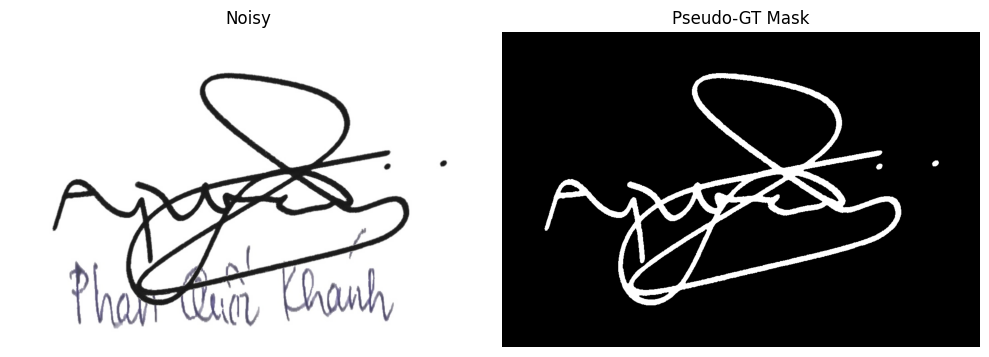

In [8]:
def show_mask_for_pair(dl_pair):
    noisy_path, mask_path = dl_pair
    noisy = np.array(Image.open(noisy_path).convert("RGB"))
    mask_path = Path(mask_path)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(noisy); plt.title("Noisy"); plt.axis("off")
    plt.subplot(1,2,2)
    if mask_path.exists():
        mask = np.array(Image.open(mask_path).convert("L"))
        plt.imshow(mask, cmap="gray"); plt.title("Pseudo-GT Mask"); plt.axis("off")
    else:
        plt.text(0.1, 0.5, f"Missing:\n{mask_path}", fontsize=10); plt.axis("off")
    plt.tight_layout(); plt.show()

show_mask_for_pair(random.choice(dl_train))

In [32]:
def conv_bn_relu(x, filters, k=3, s=1, dilation=1, name=None):
    x = tf.keras.layers.Conv2D(filters, k, strides=s, padding="same",
                               dilation_rate=dilation, use_bias=False,
                               name=None if name is None else name+"_conv")(x)
    x = tf.keras.layers.BatchNormalization(name=None if name is None else name+"_bn")(x)
    x = tf.keras.layers.ReLU(name=None if name is None else name+"_relu")(x)
    return x

def aspp(x, out_filters=256, atrous_rates=(6,12,18), name="aspp"):
    h, w = x.shape[1], x.shape[2]

    b0 = conv_bn_relu(x, out_filters, k=1, name=name+"_b0")
    b1 = conv_bn_relu(x, out_filters, k=3, dilation=atrous_rates[0], name=name+"_b1")
    b2 = conv_bn_relu(x, out_filters, k=3, dilation=atrous_rates[1], name=name+"_b2")
    b3 = conv_bn_relu(x, out_filters, k=3, dilation=atrous_rates[2], name=name+"_b3")

    b4 = tf.keras.layers.GlobalAveragePooling2D(name=name+"_gap")(x)
    b4 = tf.keras.layers.Reshape((1,1,x.shape[-1]), name=name+"_reshape")(b4)
    b4 = conv_bn_relu(b4, out_filters, k=1, name=name+"_b4")
    b4 = tf.keras.layers.UpSampling2D(size=(h,w), interpolation="bilinear", name=name+"_b4_up")(b4)

    y = tf.keras.layers.Concatenate(name=name+"_concat")([b0,b1,b2,b3,b4])
    y = conv_bn_relu(y, out_filters, k=1, name=name+"_proj")
    y = tf.keras.layers.Dropout(0.1, name=name+"_drop")(y)
    return y

def DeeplabV3Plus_MobileNetV2(input_shape=(512,512,3), backbone_trainable=False):
    inputs = tf.keras.Input(shape=input_shape)

    backbone = tf.keras.applications.MobileNetV2(
        input_tensor=inputs, include_top = True, weights = "imagenet"
    )
    backbone.trainable = backbone_trainable

    x = backbone.get_layer("block_13_expand_relu").output   # stride 16
    x = aspp(x, out_filters=256, atrous_rates=(6,12,18), name="aspp")

    low = backbone.get_layer("block_3_expand_relu").output  # stride 4
    low = conv_bn_relu(low, 48, k=1, name="low_proj")

    x = tf.keras.layers.UpSampling2D(size=(4,4), interpolation="bilinear", name="up_aspp_to_low")(x)
    x = tf.keras.layers.Concatenate(name="decoder_concat")([x, low])
    x = conv_bn_relu(x, 256, k=3, name="decoder_conv1")
    x = conv_bn_relu(x, 256, k=3, name="decoder_conv2")

    x = tf.keras.layers.UpSampling2D(size=(4,4), interpolation="bilinear", name="up_to_input")(x)
    out = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", dtype="float32", name="mask")(x)  # force float32 output

    model = tf.keras.Model(inputs, out, name="DeepLabV3Plus_MobileNetV2")
    return model, backbone

In [24]:
def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])
    dice = (2.0 * inter + 1e-7) / (denom + 1e-7)
    return 1.0 - tf.reduce_mean(dice)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)

def iou(y_true, y_pred, thr=0.35):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > thr, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + 1e-7) / (union + 1e-7))

def precision(y_true, y_pred, thr=0.35):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > thr, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=[1,2,3])
    return tf.reduce_mean((tp + 1e-7) / (tp + fp + 1e-7))

def recall(y_true, y_pred, thr=0.35):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > thr, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=[1,2,3])
    return tf.reduce_mean((tp + 1e-7) / (tp + fn + 1e-7))

def f1(y_true, y_pred, thr=0.35):
    p = precision(y_true, y_pred, thr)
    r = recall(y_true, y_pred, thr)
    return (2 * p * r) / (p + r + 1e-7)

def pixel_acc(y_true, y_pred, thr=0.35):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > thr, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))

In [29]:
def _read_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0
    return img

def _read_mask(path):
    m = tf.io.read_file(path)
    m = tf.image.decode_png(m, channels=1)
    m = tf.image.resize(m, IMG_SIZE, method="nearest")
    m = tf.cast(m, tf.float32) / 255.0
    m = tf.cast(m > 0.5, tf.float32)
    return m

def make_deeplab_dataset(dl_pairs, training=True):
    img_paths  = [p[0] for p in dl_pairs]
    mask_paths = [p[1] for p in dl_pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training:
        ds = ds.shuffle(min(len(dl_pairs), 2000), seed=SEED, reshuffle_each_iteration=True)

    def _load(noisy_p, mask_p):
        x = _read_image(noisy_p)
        y = _read_mask(mask_p)
        return x, y

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_DL, drop_remainder=training).prefetch(tf.data.AUTOTUNE)
    return ds

dl_train_ds = make_deeplab_dataset(dl_train, training=True)
dl_val_ds   = make_deeplab_dataset(dl_val,   training=False)
dl_test_ds  = make_deeplab_dataset(dl_test,  training=False)

# sanity
xb, yb = next(iter(dl_train_ds))
print(xb.shape, yb.shape, xb.dtype, yb.dtype)

(8, 512, 512, 3) (8, 512, 512, 1) <dtype: 'float32'> <dtype: 'float32'>


In [35]:
tf.keras.backend.clear_session()
tf.keras.mixed_precision.set_global_policy("float32")

deeplab, backbone = DeeplabV3Plus_MobileNetV2(input_shape=(512,512,3), backbone_trainable=False)

deeplab.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss,
    metrics=[iou, precision, recall, f1, pixel_acc]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("deeplab_best.keras", monitor="val_iou", mode="max", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_iou", mode="max", patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_iou", mode="max", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

deeplab.summary()

Model: "DeepLabV3Plus_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 256, 256,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 256, 256,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 256, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 256, 256,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 256, 256,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 256, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 257, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 128, 128,  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 128, 128,  │      2,304 │ block_1_depthwis

 Total params: 6,525,953 (24.89 MB)

 Trainable params: 5,905,505 (22.53 MB)

 Non-trainable params: 620,448 (2.37 MB)

In [36]:
history_warmup = deeplab.fit(
    dl_train_ds,
    validation_data=dl_val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
5392/5393 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1: 0.5760 - iou: 0.4787 - loss: 0.5549 - pixel_acc: 0.9615 - precision: 0.5313 - recall: 0.6353
Epoch 1: val_iou improved from None to 0.44858, saving model to deeplab_best.keras
5393/5393 ━━━━━━━━━━━━━━━━━━━━ 163s 28ms/step - f1: 0.6006 - iou: 0.5040 - loss: 0.5177 - pixel_acc: 0.9651 - precision: 0.5575 - recall: 0.6538 - val_f1: 0.5703 - val_iou: 0.4486 - val_loss: 0.5596 - val_pixel_acc: 0.9603 - val_precision: 0.4958 - val_recall: 0.6747 - learning_rate: 0.0010
Epoch 2/15
5393/5393 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1: 0.6371 - iou: 0.5386 - loss: 0.4689 - pixel_acc: 0.9690 - precision: 0.5937 - recall: 0.6893
Epoch 2: val_iou improved from 0.44858 to 0.55937, saving model to deeplab_best.keras
5393/5393 ━━━━━━━━━━━━━━━━━━━━ 147s 27ms/step - f1: 0.6403 - iou: 0.5412 - loss: 0.4653 - pixel_acc: 0.9691 - precision: 0.5972 - recall: 0.6920 - val_f1: 0.6637 - val_iou: 0.5594 - val_loss: 0.4424 - val_pixel_acc: 0.9662 - val_pr

In [37]:
# Unfreeze last blocks
backbone.trainable = True
set_trainable = False
for layer in backbone.layers:
    if layer.name == "block_13_expand":
        set_trainable = True
    layer.trainable = set_trainable

# Freeze all BN (critical)
for layer in deeplab.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

deeplab.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss,
    metrics=[iou, precision, recall, f1, pixel_acc]
)

history_ft = deeplab.fit(
    dl_train_ds,
    validation_data=dl_val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
5392/5393 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1: 0.6759 - iou: 0.5691 - loss: 0.4274 - pixel_acc: 0.9730 - precision: 0.6293 - recall: 0.7324
Epoch 1: val_iou did not improve from 0.60258
5393/5393 ━━━━━━━━━━━━━━━━━━━━ 161s 28ms/step - f1: 0.6886 - iou: 0.5831 - loss: 0.4079 - pixel_acc: 0.9739 - precision: 0.6423 - recall: 0.7437 - val_f1: 0.6880 - val_iou: 0.5876 - val_loss: 0.4011 - val_pixel_acc: 0.9752 - val_precision: 0.6499 - val_recall: 0.7316 - learning_rate: 0.0010
Epoch 2/10
5393/5393 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1: 0.7019 - iou: 0.5969 - loss: 0.3886 - pixel_acc: 0.9753 - precision: 0.6553 - recall: 0.7572
Epoch 2: val_iou did not improve from 0.60258

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5393/5393 ━━━━━━━━━━━━━━━━━━━━ 146s 27ms/step - f1: 0.7016 - iou: 0.5962 - loss: 0.3896 - pixel_acc: 0.9750 - precision: 0.6548 - recall: 0.7570 - val_f1: 0.6912 - val_iou: 0.5926 - val_loss: 0.3984 - val_pixel_acc: 0.9762 - val_pr

In [38]:
deeplab = tf.keras.models.load_model("deeplab_best.keras", compile=False)

deeplab.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=bce_dice_loss,
    metrics=[iou, precision, recall, f1, pixel_acc]
)

test_vals = deeplab.evaluate(dl_test_ds, verbose=1)
print(dict(zip(deeplab.metrics_names, test_vals)))

675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - f1: 0.7042 - iou: 0.6045 - loss: 0.3862 - pixel_acc: 0.9773 - precision: 0.6757 - recall: 0.7358
{'loss': 0.3861973285675049, 'compile_metrics': 0.6044981479644775}


In [16]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")

In [17]:
def read_rgb_01(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0
    return img

def deeplab_prob_map(model, x_rgb_01):
    p = model(tf.expand_dims(x_rgb_01, 0), training=False)[0, ..., 0]  # (H,W)
    return tf.expand_dims(p, -1)  # (H,W,1)

def make_pix2pix_dataset(pairs, deeplab_model, training=True):
    noisy_paths = [p[0] for p in pairs]
    clean_paths = [p[1] for p in pairs]
    ds = tf.data.Dataset.from_tensor_slices((noisy_paths, clean_paths))

    if training:
        ds = ds.shuffle(min(len(pairs), 2000), seed=SEED, reshuffle_each_iteration=True)

    def _load(noisy_p, clean_p):
        x = read_rgb_01(noisy_p)
        y = read_rgb_01(clean_p)
        p = deeplab_prob_map(deeplab_model, x)
        x4 = tf.concat([x, p], axis=-1)

        # to [-1,1]
        x4 = (x4 * 2.0) - 1.0
        y  = (y  * 2.0) - 1.0
        return x4, y

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_GAN, drop_remainder=training).prefetch(tf.data.AUTOTUNE)
    return ds

pix_train_ds = make_pix2pix_dataset(pix_train, deeplab, training=True)
pix_val_ds   = make_pix2pix_dataset(pix_val,   deeplab, training=False)
pix_test_ds  = make_pix2pix_dataset(pix_test,  deeplab, training=False)

x4b, yb = next(iter(pix_train_ds))
print(x4b.shape, yb.shape, x4b.dtype, yb.dtype)

(4, 512, 512, 4) (4, 512, 512, 3) <dtype: 'float32'> <dtype: 'float32'>


In [18]:
def downsample(filters, size, apply_batchnorm=True):
    init = tf.random_normal_initializer(0., 0.02)
    seq = tf.keras.Sequential()
    seq.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                                   kernel_initializer=init, use_bias=False))
    if apply_batchnorm:
        seq.add(tf.keras.layers.BatchNormalization())
    seq.add(tf.keras.layers.LeakyReLU())
    return seq

def upsample(filters, size, apply_dropout=False):
    init = tf.random_normal_initializer(0., 0.02)
    seq = tf.keras.Sequential()
    seq.add(tf.keras.layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                            kernel_initializer=init, use_bias=False))
    seq.add(tf.keras.layers.BatchNormalization())
    if apply_dropout:
        seq.add(tf.keras.layers.Dropout(0.5))
    seq.add(tf.keras.layers.ReLU())
    return seq

def Generator(input_channels=4):
    inputs = tf.keras.layers.Input(shape=[IMG_SIZE[0], IMG_SIZE[1], input_channels])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]

    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    init = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                           kernel_initializer=init,
                                           activation='tanh',
                                           dtype="float32")  # output float32

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x, name="pix2pix_generator")

def Discriminator(input_channels=4):
    init = tf.random_normal_initializer(0., 0.02)
    inp = tf.keras.layers.Input(shape=[IMG_SIZE[0], IMG_SIZE[1], input_channels], name='input')
    tar = tf.keras.layers.Input(shape=[IMG_SIZE[0], IMG_SIZE[1], 3], name='target')

    x = tf.keras.layers.Concatenate()([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1, kernel_initializer=init, use_bias=False)(zero_pad1)
    bn1 = tf.keras.layers.BatchNormalization()(conv)
    leaky = tf.keras.layers.LeakyReLU()(bn1)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky)
    last = tf.keras.layers.Conv2D(1, 4, strides=1, kernel_initializer=init)(zero_pad2)
    return tf.keras.Model(inputs=[inp, tar], outputs=last, name="pix2pix_discriminator")

generator = Generator(input_channels=4)
discriminator = Discriminator(input_channels=4)

In [19]:
LAMBDA_L1 = 100.0
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True, reduction="none")

def discriminator_loss(disc_real, disc_fake):
    disc_real = tf.cast(disc_real, tf.float32)
    disc_fake = tf.cast(disc_fake, tf.float32)
    real_loss = tf.reduce_mean(loss_obj(tf.ones_like(disc_real), disc_real))
    fake_loss = tf.reduce_mean(loss_obj(tf.zeros_like(disc_fake), disc_fake))
    return real_loss + fake_loss

def generator_gan_loss(disc_fake):
    disc_fake = tf.cast(disc_fake, tf.float32)
    return tf.reduce_mean(loss_obj(tf.ones_like(disc_fake), disc_fake))

def weighted_l1_loss(x4, y_true, y_pred, alpha=3.0):
    # force float32 for mixed precision stability
    x4 = tf.cast(x4, tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    p = (x4[..., 3:4] + 1.0) / 2.0      # guidance prob back to [0,1]
    w = 1.0 + alpha * p                  # higher weight on signature region
    return tf.reduce_mean(w * tf.abs(y_true - y_pred))

def generator_total_loss(disc_fake, x4, y_true, y_pred):
    gan = generator_gan_loss(disc_fake)
    l1  = weighted_l1_loss(x4, y_true, y_pred, alpha=3.0)
    return gan + LAMBDA_L1 * l1, gan, l1

gen_opt  = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step(x4, y):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        y_pred = generator(x4, training=True)
        disc_real = discriminator([x4, y], training=True)
        disc_fake = discriminator([x4, y_pred], training=True)

        gen_total, gen_gan, gen_l1 = generator_total_loss(disc_fake, x4, y, y_pred)
        disc_loss = discriminator_loss(disc_real, disc_fake)

    gen_grads  = gen_tape.gradient(gen_total, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_opt.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_opt.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return gen_total, gen_gan, gen_l1, disc_loss

In [20]:
def fit_pix2pix(train_ds, epochs=5, save_every=1):
    for epoch in range(1, epochs+1):
        pbar = tqdm(train_ds, desc=f"Epoch {epoch}/{epochs}", leave=True)
        for x4, y in pbar:
            gen_total, gen_gan, gen_l1, disc_loss = train_step(x4, y)
            pbar.set_postfix({
                "g_total": float(tf.reduce_mean(gen_total).numpy()),
                "g_l1":    float(tf.reduce_mean(gen_l1).numpy()),
                "d":       float(tf.reduce_mean(disc_loss).numpy()),
            })

        if epoch % save_every == 0:
            generator.save(f"pix2pix_gen_e{epoch}.keras", include_optimizer=False)

# Start small first (you complained about time). Increase after sanity check.
fit_pix2pix(pix_train_ds, epochs=3, save_every=1)

Epoch 3/3: 100%|██████████| 10786/10786 [19:47<00:00,  9.08it/s, g_total=5.22, g_l1=0.0362, d=1.03]  


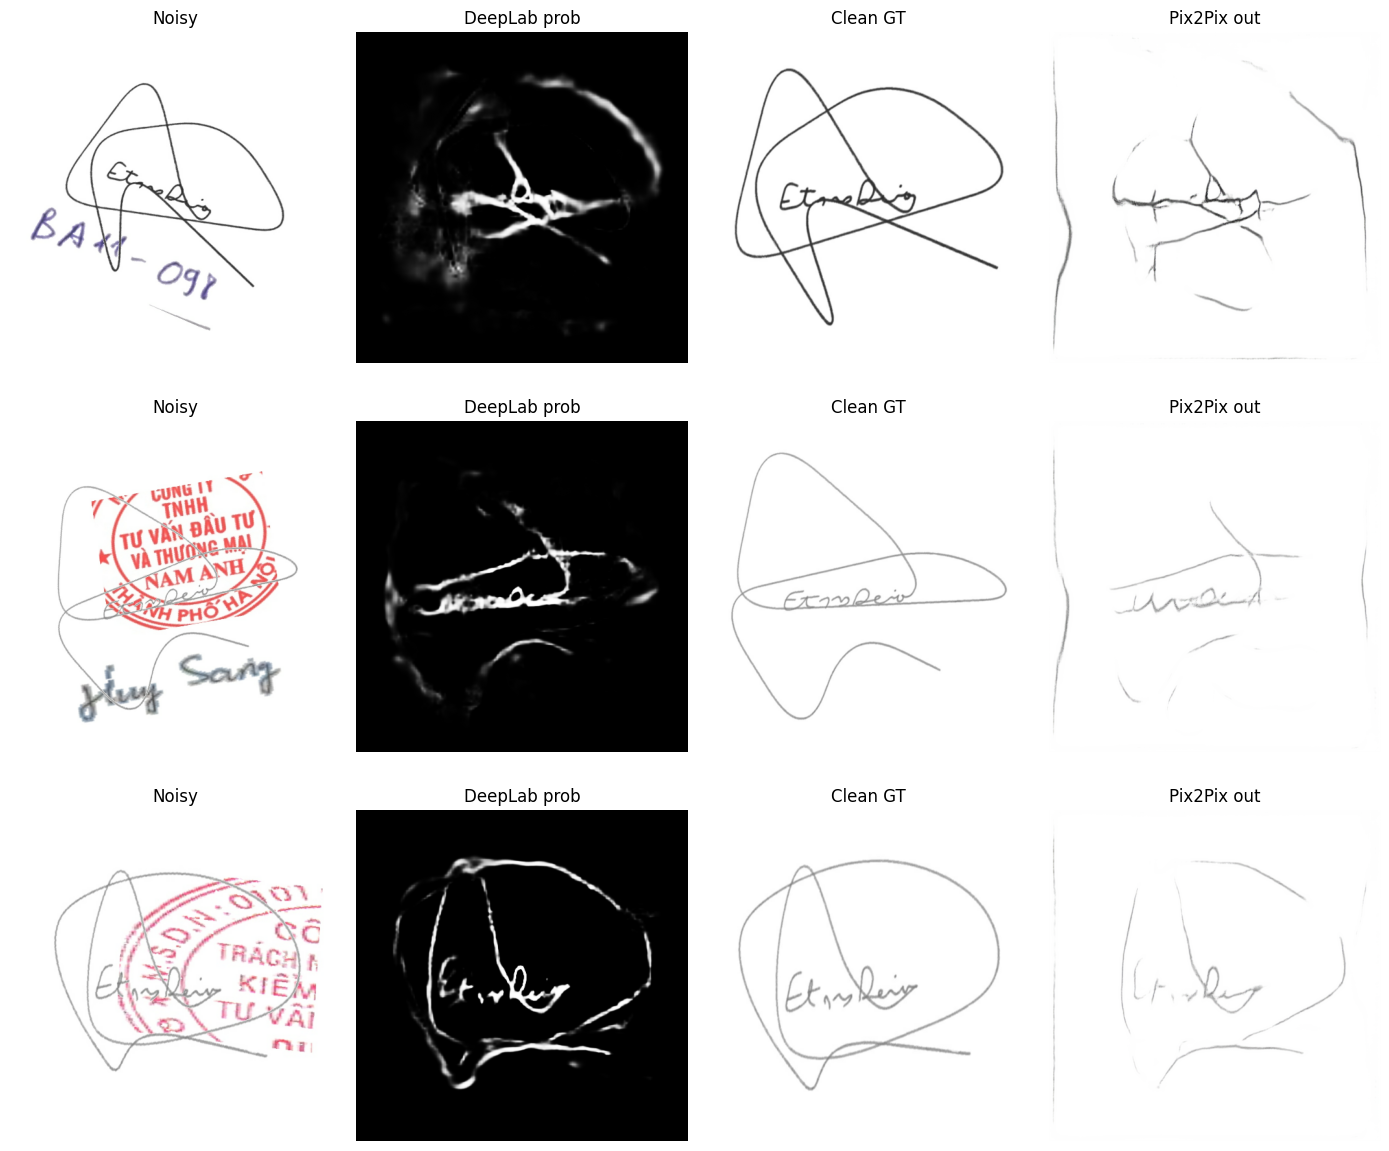

In [21]:
def denorm01(x):
    return (x + 1.0) / 2.0

def show_pix2pix_samples(ds, n=3):
    x4, y = next(iter(ds))
    y_pred = generator(x4, training=False)

    x_rgb = denorm01(x4[..., :3]).numpy()
    p_map = denorm01(x4[..., 3:4]).numpy()[...,0]
    y_true = denorm01(y).numpy()
    y_out  = denorm01(y_pred).numpy()

    n = min(n, x4.shape[0])
    plt.figure(figsize=(14, 4*n))
    for i in range(n):
        plt.subplot(n,4,4*i+1); plt.imshow(x_rgb[i]); plt.title("Noisy"); plt.axis("off")
        plt.subplot(n,4,4*i+2); plt.imshow(p_map[i], cmap="gray"); plt.title("DeepLab prob"); plt.axis("off")
        plt.subplot(n,4,4*i+3); plt.imshow(y_true[i]); plt.title("Clean GT"); plt.axis("off")
        plt.subplot(n,4,4*i+4); plt.imshow(y_out[i]); plt.title("Pix2Pix out"); plt.axis("off")
    plt.tight_layout(); plt.show()

show_pix2pix_samples(pix_val_ds, n=3)

In [65]:
def preprocess_image_rgb01(path):
    img = Image.open(path).convert("RGB")
    orig = np.array(img)
    x = tf.image.resize(orig, IMG_SIZE, method="bilinear")
    x = tf.cast(x, tf.float32) / 255.0
    return orig, x

def postprocess_mask(mask01, close_ksize=3, close_iter=1):
    m = (mask01 * 255).astype(np.uint8)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=close_iter)
    return (m > 127).astype(np.uint8)

def run_full_pipeline(noisy_path, thr=0.35, do_post=True):
    orig, x = preprocess_image_rgb01(noisy_path)  # x: (512,512,3) [0,1]

    # # guidance from deeplab on noisy
    # p = deeplab_prob_map(deeplab, x)              # (512,512,1)
    # x4 = tf.concat([x, p], axis=-1)
    # x4 = (x4 * 2.0) - 1.0
    # x4 = tf.expand_dims(x4, 0)

    # # pix2pix cleaned
    # y_pred = generator(x4, training=False)[0]     # [-1,1]
    # clean01 = tf.clip_by_value((y_pred + 1.0)/2.0, 0.0, 1.0).numpy()  # [0,1]
    clean_u8 = (x.numpy() * 255).astype(np.uint8)

    # deeplab on cleaned image
    prob = deeplab.predict(np.expand_dims(x, 0), verbose=0)[0, ..., 0]  # (512,512)
    mask = (prob >= thr).astype(np.uint8)
    if do_post:
        mask = postprocess_mask(mask, close_ksize=3, close_iter=1)

    # resize mask back to orig size and extract
    mask_orig = cv2.resize(mask, (orig.shape[1], orig.shape[0]), interpolation=cv2.INTER_NEAREST)
    extracted = orig.copy()
    # extracted[mask_orig < thr] = 255


    m = (mask_orig * 255).astype(np.uint8) if mask_orig.max() <= 1 else mask_orig
    _, binary = cv2.threshold(m, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = (binary > 0).astype(np.uint8)
    extracted = binary.copy()
    
    return orig, clean_u8, prob, mask, extracted, mask_orig

def show_full_pipeline(noisy_path, thr=0.35):
    orig, clean_u8, prob, mask, extracted, mask_orig = run_full_pipeline(noisy_path, thr=thr)

    plt.figure(figsize=(18,4))
    plt.subplot(1,6,1); plt.imshow(orig); plt.title("Input noisy"); plt.axis("off")
    plt.subplot(1,6,2); plt.imshow(clean_u8); plt.title("Pix2Pix cleaned"); plt.axis("off")
    plt.subplot(1,6,3); plt.imshow(prob, cmap="gray"); plt.title("DeepLab prob"); plt.axis("off")
    plt.subplot(1,6,4); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
    plt.subplot(1,6,5); plt.imshow(extracted, cmap = "gray"); plt.title("Extracted signature"); plt.axis("off")
    plt.subplot(1,6,6); plt.imshow(mask_orig); plt.title("Mask_Orig"); plt.axis("off")
    plt.tight_layout(); plt.show()

# Example usage:
# show_full_pipeline("data/3990/cf-3990-60.jpg", thr=0.35)

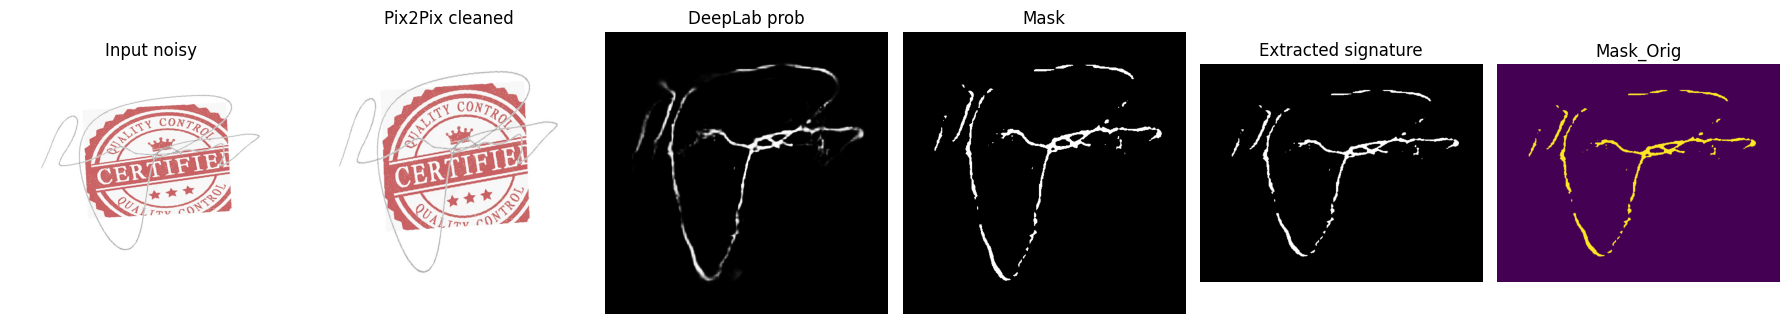

In [66]:
show_full_pipeline("vault/3020/cf-3020-48.jpg", thr=0.35)

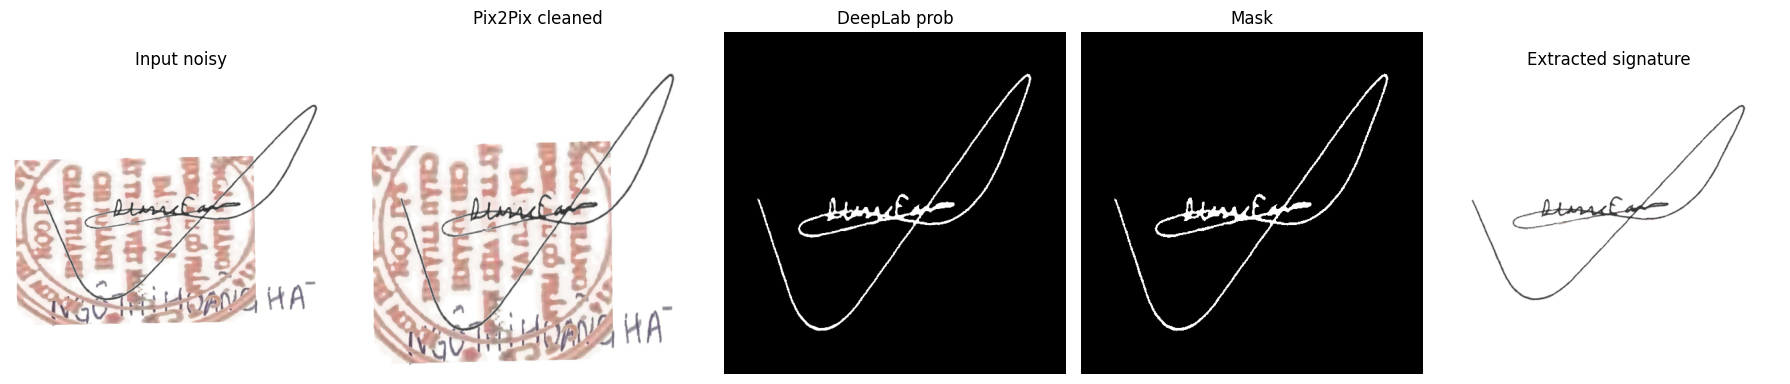

In [52]:
show_full_pipeline("vault/3990/cf-3990-60.jpg", thr=0.35)